Importing Libraries

In [80]:
import pandas as pd
import os


File Loading

In [81]:
# Since your files are in the same folder as the notebook, leave this empty
DATA_DIR = "data"

# Updated paths matching your exact file structure and names
results_path = os.path.join(DATA_DIR, "results.csv")
rankings_path = os.path.join(DATA_DIR, "fifa_ranking.csv")  # Fixed spelling to singular
values_path = os.path.join(DATA_DIR, "team_value.csv")
players_path = os.path.join(DATA_DIR, "player_rating.csv")
squads_path = os.path.join(DATA_DIR, "wc2026_squads.csv")
distances_path = os.path.join(DATA_DIR, "dist_travelled.csv")

print("🔄 Loading all 6 datasets...")
df_results = pd.read_csv(results_path)
df_rankings = pd.read_csv(rankings_path)
df_values = pd.read_csv(values_path)
df_players = pd.read_csv(players_path)
df_squads = pd.read_csv(squads_path)
df_distances = pd.read_csv(distances_path)

print("✅ All files loaded successfully!")

🔄 Loading all 6 datasets...
✅ All files loaded successfully!


Getting qualifying countries and storing them

In [82]:
df_squads.columns = df_squads.columns.str.lower()
df_results.columns = df_results.columns.str.lower()
df_rankings.columns = df_rankings.columns.str.lower()
df_values.columns = df_values.columns.str.lower()
df_players.columns = df_players.columns.str.lower()
df_distances.columns = df_distances.columns.str.lower()

qualifying_countries = df_squads['country'].unique()
print(f"Number of qualifying countries found: {len(qualifying_countries)}")
print(qualifying_countries)

Number of qualifying countries found: 48
['Algeria' 'Argentina' 'Australia' 'Austria' 'Belgium'
 'Bosnia And Herzegovina' 'Brazil' 'Cabo Verde' 'Canada' 'Colombia'
 'Congo DR' 'Ivory Coast' 'Croatia' 'Curacao' 'Czechia' 'Ecuador' 'Egypt'
 'England' 'France' 'Germany' 'Ghana' 'Haiti' 'Iran' 'Iraq' 'Japan'
 'Jordan' 'Korea Republic' 'Mexico' 'Morocco' 'Netherlands' 'New Zealand'
 'Norway' 'Panama' 'Paraguay' 'Portugal' 'Qatar' 'Saudi Arabia' 'Scotland'
 'Senegal' 'South Africa' 'Spain' 'Sweden' 'Switzerland' 'Tunisia'
 'Turkiye' 'Uruguay' 'USA' 'Uzbekistan']


Ensuring consistency across all qualifying country names

In [83]:
# Create a quick function to see what countries aren't matching up (Case-Insensitive)
all_datasets = {}

# 1. Handle df_results checking for home_country and away_country explicitly
if 'home_country' in df_results.columns:
    all_datasets['results'] = set(df_results['home_country'].unique()).union(set(df_results['away_country'].unique()))
else:
    all_datasets['results'] = set(df_results['home_team'].unique()).union(set(df_results['away_team'].unique()))

# 2. Safely find the 'country' column regardless of capitalization in the other dataframes
for name, df in [('rankings', df_rankings), ('values', df_values), ('players', df_players)]:
    country_col = [col for col in df.columns if 'country' in col.lower()]
    if country_col:
        all_datasets[name] = set(df[country_col[0]].unique())
    else:
        all_datasets[name] = set()

# 3. Run the missing check comparison safely
print("🔄 Searching for unmatched countries in datasets...")
for name, country_set in all_datasets.items():
    # Strip whitespace and convert everything to a uniform comparison set
    clean_set = {str(c).strip().lower() for c in country_set}
    missing = [c for c in qualifying_countries if str(c).strip().lower() not in clean_set]
    
    if missing:
        print(f"⚠️ '{name}' dataset is missing or spells these qualifying countries differently: {missing}")
    else:
        print(f"✅ '{name}' dataset matches your qualifying countries perfectly!")

🔄 Searching for unmatched countries in datasets...
⚠️ 'results' dataset is missing or spells these qualifying countries differently: ['Cabo Verde', 'Congo DR', 'Curacao', 'Czechia', 'Korea Republic', 'Turkiye', 'USA']
⚠️ 'rankings' dataset is missing or spells these qualifying countries differently: ['Congo DR', 'Iran']
⚠️ 'values' dataset is missing or spells these qualifying countries differently: ['Bosnia And Herzegovina', 'Cabo Verde', 'Congo DR', 'Curacao', 'Korea Republic', 'USA']
⚠️ 'players' dataset is missing or spells these qualifying countries differently: ['Ivory Coast', 'USA']


In [84]:
# 1. Map lowercased variations -> exact squad list values (Title/UPPER case)
country_mapping = {
    'bosnia and herzegovina': 'Bosnia And Herzegovina',
    'cape verde': 'Cabo Verde',
    'dr congo': 'Congo DR',
    'congo dr': 'Congo DR',
    'congo': 'Congo DR',
    'democratic republic of the congo': 'Congo DR',
    'congo, democratic republic of the': 'Congo DR',
    'curaçao': 'Curacao',
    'curacao': 'Curacao',
    'czech republic': 'Czechia',
    'czechia': 'Czechia',
    'south korea': 'Korea Republic',
    'korea republic': 'Korea Republic',
    'turkey': 'Turkiye',
    'turkiye': 'Turkiye',
    'united states': 'USA',
    'usa': 'USA',
    'iran, islamic republic of': 'Iran',
    'ir iran': 'Iran',
    'iran': 'Iran',
    'ivory coast': 'Ivory Coast',
    "côte d'ivoire": 'Ivory Coast',
    "cote d'ivoire": 'Ivory Coast',
    'bosnia-herzegovina': 'Bosnia And Herzegovina',
}

# 2. Map and update values using lowercased keys safely
for df in [df_results, df_rankings, df_values, df_players]:
    if 'country' in df.columns:
        df['country'] = df['country'].astype(str).str.lower().str.strip().map(country_mapping).fillna(df['country'])
        
    if 'home_country' in df.columns:
        df['home_country'] = df['home_country'].astype(str).str.lower().str.strip().map(country_mapping).fillna(df['home_country'])
        
    if 'away_country' in df.columns:
        df['away_country'] = df['away_country'].astype(str).str.lower().str.strip().map(country_mapping).fillna(df['away_country'])

print("🔄 Re-running the clean validation check...")

# 3. Validation Check (Using fixed column names)
all_datasets = {
    'results': set(df_results['home_country'].unique()).union(set(df_results['away_country'].unique())),
    'rankings': set(df_rankings['country'].unique()),
    'values': set(df_values['country'].unique()),
    'players': set(df_players['country'].unique())
}

# Ensure your master checklist is strings
qualifying_countries_clean = [str(c).strip() for c in qualifying_countries]

for name, country_set in all_datasets.items():
    clean_set = {str(c).strip() for c in country_set}
    missing = [c for c in qualifying_countries_clean if c not in clean_set]
    print(f"👉 '{name}' dataset missing count: {len(missing)} countries")
    if missing:
        print(f"   Missing items: {missing}")

🔄 Re-running the clean validation check...
👉 'results' dataset missing count: 0 countries
👉 'rankings' dataset missing count: 0 countries
👉 'values' dataset missing count: 0 countries
👉 'players' dataset missing count: 0 countries


Filtering out qualifying countries in all datasets

In [85]:
# 1. Ensure strings are stripped and lowercased for accurate filtering
df_results['home_country'] = df_results['home_country'].astype(str).str.strip()
df_results['away_country'] = df_results['away_country'].astype(str).str.strip()
qualifying_countries_clean = [str(c).strip() for c in qualifying_countries]

# 2. Keep matches where BOTH competing nations are in your World Cup list
df_results_filtered = df_results[
    df_results['home_country'].isin(qualifying_countries_clean) & 
    df_results['away_country'].isin(qualifying_countries_clean)
].copy()

print(f"✅ Total historical match records found matching your squads: {len(df_results_filtered)}")
if len(df_results_filtered) == 0:
    print("⚠️ Warning: Still 0 matches. Printing a few unique team names from your results dataset to inspect:")
    print(list(df_results['home_country'].unique())[:10])

✅ Total historical match records found matching your squads: 7657


Filtering and merging Player ratings with squds

In [86]:
# 1. Clean basic strings
df_players['name_lower'] = df_players['name'].astype(str).str.lower().str.strip()
df_squads['player_name_lower'] = df_squads['player name'].astype(str).str.lower().str.strip()

# 2. Step 1: Exact Match across the whole dataset (ignoring country columns for a second)
name_to_rating = dict(zip(df_players['name_lower'], df_players['overall']))
df_squad_ratings = df_squads.copy()
df_squad_ratings['overall'] = df_squad_ratings['player_name_lower'].map(name_to_rating)

print(f"📋 Roster size: {len(df_squads)}")
print(f"🔍 Exact name matches (global): {df_squad_ratings['overall'].notna().sum()}")

# 3. Step 2: Token / Sub-word Matching Fallback
unmatched_mask = df_squad_ratings['overall'].isna()

if unmatched_mask.any():
    print("⚠️ Executing deep token matching fallback...")
    
    # Build a lookup pool of players. Skip short initials like "j.", "de", "v"
    player_pool = []
    for _, row in df_players.iterrows():
        tokens = [t for t in row['name_lower'].split() if len(t) > 2]
        player_pool.append({'tokens': tokens, 'rating': row['overall'], 'full': row['name_lower']})
        
    # Match unmatched squad rows
    for idx, row in df_squad_ratings[unmatched_mask].iterrows():
        squad_name = row['player_name_lower']
        squad_tokens = [t for t in squad_name.split() if len(t) > 2]
        
        best_match_rating = None
        
        for p in player_pool:
            # Check if they share significant name tokens (e.g., "mbappe" or "messi")
            # Or if one full name string is inside the other
            if any(t in squad_name for t in p['tokens']) or p['full'] in squad_name:
                best_match_rating = p['rating']
                break # Take the first solid match
                
        if best_match_rating is not None:
            df_squad_ratings.at[idx, 'overall'] = best_match_rating

# 4. Final safety fill
final_unmatched = df_squad_ratings['overall'].isna().sum()
df_squad_ratings['overall'] = df_squad_ratings['overall'].fillna(70)

print(f"🎉 Deep match complete. Unmatched defaulting to 70: {final_unmatched}")

📋 Roster size: 1248
🔍 Exact name matches (global): 35
⚠️ Executing deep token matching fallback...
🎉 Deep match complete. Unmatched defaulting to 70: 55


Finding each squad's avg stats by EA FC rating

In [87]:
# Clean up the position column strings just in case
df_squad_ratings['position'] = df_squad_ratings['position'].astype(str).str.lower().str.strip()

# Group by country and position to find the mean rating
pos_averages = df_squad_ratings.groupby(['country', 'position'])['overall'].mean().unstack()

# Structure the newborn positional columns clearly
pos_averages.columns = [f'avg_{col}' for col in pos_averages.columns]
pos_averages = pos_averages.reset_index()

# Handle any missing positions by filling them with the country's general average roster rating
fallback_avg = df_squad_ratings.groupby('country')['overall'].mean().reset_index()
for col in ['avg_df', 'avg_mf', 'avg_fw', 'avg_gk']:
    if col in pos_averages.columns:
        pos_averages[col] = pos_averages[col].fillna(pos_averages['country'].map(fallback_avg.set_index('country')['overall']))

# Apply your custom weights (Giving lower weight to Goalkeeper as requested)
pos_averages['weighted_squad_strength'] = (
    (pos_averages['avg_fw'] * 0.32) + 
    (pos_averages['avg_mf'] * 0.32) + 
    (pos_averages['avg_df'] * 0.31) + 
    (pos_averages['avg_gk'] * 0.05)
)

# Round all calculated numeric columns to the nearest whole number
numeric_cols = ['avg_df', 'avg_mf', 'avg_fw', 'avg_gk', 'weighted_squad_strength']
pos_averages[numeric_cols] = pos_averages[numeric_cols].round(0).astype(int)

print("📊 Calculated positional averages and overall squad weights (Rounded):")
print(pos_averages[['country', 'avg_df', 'avg_mf', 'avg_fw', 'avg_gk', 'weighted_squad_strength']].head())

📊 Calculated positional averages and overall squad weights (Rounded):
     country  avg_df  avg_mf  avg_fw  avg_gk  weighted_squad_strength
0    Algeria      73      75      76      72                       75
1  Argentina      76      82      80      67                       79
2  Australia      73      76      70      79                       73
3    Austria      77      78      72      72                       75
4    Belgium      73      81      81      63                       77


In [89]:
import pandas as pd

# 1. DO NOT reload from disk. Instead, make a fresh deep copy of the dataframe already in memory
# If your original variable name wasn't df_rankings, change the name on the right side of the '=' sign.
df_rankings_clean = df_rankings.copy()

# 2. Dynamically find the date column
rank_date_col = [col for col in df_rankings_clean.columns if 'date' in col or 'year' in col]
actual_col = rank_date_col[0]

# 3. Parse dates letting pandas infer the format automatically
df_rankings_clean['parsed_date'] = pd.to_datetime(df_rankings_clean[actual_col], errors='coerce')

# 4. Filter records from January 1, 2024 onwards
df_recent_rankings = df_rankings_clean[df_rankings_clean['parsed_date'] >= '2024-01-01'].sort_values('parsed_date')

print(f"📊 Filtered down to {len(df_recent_rankings)} ranking records from Jan 2024 to present.")

if len(df_recent_rankings) == 0:
    print(f"⚠️ 0 rows. Showing the unique values inside your '{actual_col}' column to see why the filter missed:")
    print(df_rankings_clean[actual_col].dropna().unique()[:5])
else:
    # 5. Extract latest metrics
    df_latest = df_recent_rankings.groupby('country').last().reset_index()
    df_latest_rank = df_latest[['country', 'rank', 'total_points']].copy()
    df_latest_rank['total_points'] = df_latest_rank['total_points'].round(0).astype(int)

    # 6. Calculate rank momentum
    df_earliest = df_recent_rankings.groupby('country').first().reset_index()

    df_momentum = pd.DataFrame({
        'country': df_latest['country'].astype(str).str.strip(),
        'current_rank': df_latest['rank'],
        'current_points': df_latest_rank['total_points'],
        'two_year_rank_momentum': df_earliest['rank'] - df_latest['rank']
    })

    print("\n🏅 FIFA 2-Year Rankings Summary Complete:")
    print(df_momentum.head())

📊 Filtered down to 633 ranking records from Jan 2024 to present.

🏅 FIFA 2-Year Rankings Summary Complete:
          country  current_rank  current_points  two_year_rank_momentum
0     Afghanistan         151.0            1034                     7.0
1         Albania          66.0            1379                    -2.0
2         Algeria          44.0            1474                    -1.0
3  American Samoa         188.0             891                     0.0
4         Andorra         162.0             996                     2.0


In [90]:
print("🔀 Merging 2-year form features into match outcomes...")

# Automatically detect whatever the value column is named in df_values
val_col = [col for col in df_values.columns if 'val' in col or 'market' in col]
val_name = val_col[0] if val_col else df_values.columns[-1]

# 1. Merge Home country metrics
df_merged = pd.merge(df_results_filtered, df_values[['country', val_name]], left_on='home_country', right_on='country', how='left').rename(columns={val_name: 'home_value'}).drop(columns=['country'], errors='ignore')
df_merged = pd.merge(df_merged, df_momentum, left_on='home_country', right_on='country', how='left').rename(
    columns={'current_rank': 'home_rank', 'current_points': 'home_points', 'two_year_rank_momentum': 'home_momentum'}
).drop(columns=['country'], errors='ignore')
df_merged = pd.merge(df_merged, pos_averages, left_on='home_country', right_on='country', how='left').rename(columns={'weighted_squad_strength': 'home_squad_rating'}).drop(columns=['country'], errors='ignore')

# 2. Merge Away country metrics
df_merged = pd.merge(df_merged, df_values[['country', val_name]], left_on='away_country', right_on='country', how='left').rename(columns={val_name: 'away_value'}).drop(columns=['country'], errors='ignore')
df_merged = pd.merge(df_merged, df_momentum, left_on='away_country', right_on='country', how='left').rename(
    columns={'current_rank': 'away_rank', 'current_points': 'away_points', 'two_year_rank_momentum': 'away_momentum'}
).drop(columns=['country'], errors='ignore')
df_merged = pd.merge(df_merged, pos_averages, left_on='away_country', right_on='country', how='left').rename(columns={'weighted_squad_strength': 'away_squad_rating'}).drop(columns=['country'], errors='ignore')

# 3. Create Target (y) and mathematical Difference Features (X)
df_merged['total_goals'] = df_merged['home_score'] + df_merged['away_score']
df_merged['rank_diff'] = df_merged['home_rank'] - df_merged['away_rank']
df_merged['value_diff'] = df_merged['home_value'] - df_merged['away_value']
df_merged['rating_diff'] = df_merged['home_squad_rating'] - df_merged['away_squad_rating']
df_merged['momentum_diff'] = df_merged['home_momentum'] - df_merged['away_momentum']

# Drop rows with missing values to keep our data clean for PyTorch
features_to_keep = ['home_country', 'away_country', 'rank_diff', 'value_diff', 'rating_diff', 'momentum_diff', 'total_goals']
df_final = df_merged.dropna(subset=['rank_diff', 'value_diff', 'rating_diff', 'momentum_diff', 'total_goals'])[features_to_keep]

print(f"\n✅ DATA CLEANING STAGE COMPLETE!")
print(f"Total structured matches ready for PyTorch Linear Regression: {len(df_final)}")
print(df_final.head())

🔀 Merging 2-year form features into match outcomes...

✅ DATA CLEANING STAGE COMPLETE!
Total structured matches ready for PyTorch Linear Regression: 7657
  home_country away_country  rank_diff  value_diff  rating_diff  \
0     Scotland      England       34.0 -1189750000           -9   
1      England     Scotland      -34.0  1189750000            9   
2     Scotland      England       34.0 -1189750000           -9   
3      England     Scotland      -34.0  1189750000            9   
4     Scotland      England       34.0 -1189750000           -9   

   momentum_diff  total_goals  
0           -3.0            0  
1            3.0            6  
2           -3.0            3  
3            3.0            4  
4           -3.0            3  


Sanity check to make sure all data has been cleaned and entered

🔍 RUNNING RAW DATA SANITY CHECK...

📊 Feature Summary Statistics:
       rank_diff    value_diff  rating_diff  momentum_diff  total_goals
count    7657.00  7.657000e+03      7657.00        7657.00      7657.00
mean       -2.60  2.509417e+07         0.10           0.12         2.81
std        27.76  4.959767e+08         3.87           2.87         1.94
min      -105.00 -1.470750e+09       -13.00         -13.00         0.00
25%       -18.00 -2.150500e+08        -3.00          -2.00         1.00
50%        -2.00  1.085000e+07         0.00           0.00         3.00
75%        13.00  2.875000e+08         3.00           2.00         4.00
max       103.00  1.487950e+09        14.00          13.00        14.00
--------------------------------------------------

🧮 Correlation Matrix with Total Goals:
total_goals      1.000000
value_diff       0.051335
rating_diff      0.048301
momentum_diff    0.027080
rank_diff       -0.055579
Name: total_goals, dtype: float64
-------------------------------

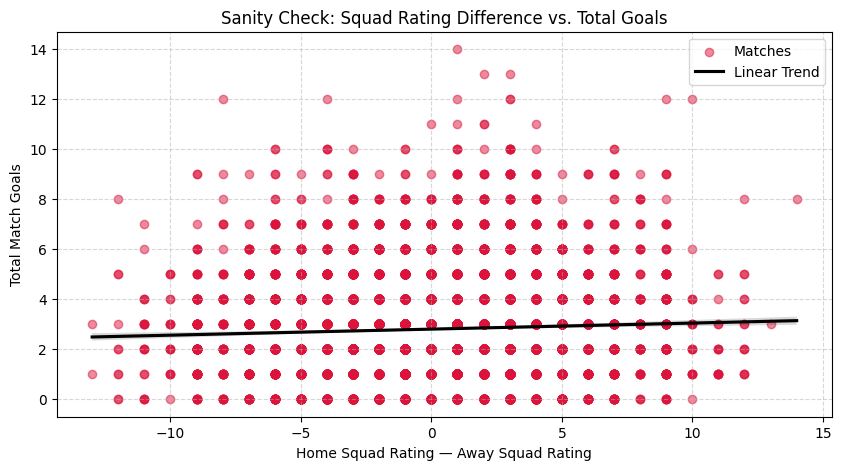

In [93]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("🔍 RUNNING RAW DATA SANITY CHECK...\n")

# 1. Print descriptive statistics to make sure numbers look realistic
print("📊 Feature Summary Statistics:")
print(df_final[['rank_diff', 'value_diff', 'rating_diff', 'momentum_diff', 'total_goals']].describe().round(2))
print("-" * 50)

# 2. Calculate a correlation matrix
# Correlation ranges from -1 to +1. 
# Near 0 means no linear relationship; closer to +1 or -1 means a strong relationship.
print("\n🧮 Correlation Matrix with Total Goals:")
corr_matrix = df_final[['rank_diff', 'value_diff', 'rating_diff', 'momentum_diff', 'total_goals']].corr()
print(corr_matrix['total_goals'].sort_values(ascending=False))
print("-" * 50)

# 3. Visual Check: Plot your best feature against Total Goals
# Usually, a massive difference in team rating or value should change how many goals are scored.
plt.figure(figsize=(10, 5))

# Scatter plot of actual data points
plt.scatter(df_final['rating_diff'], df_final['total_goals'], alpha=0.5, color='crimson', label='Matches')

# Add a trendline to see what a general linear model would assume
sns.regplot(data=df_final, x='rating_diff', y='total_goals', scatter=False, color='black', label='Linear Trend')

plt.title('Sanity Check: Squad Rating Difference vs. Total Goals')
plt.xlabel('Home Squad Rating — Away Squad Rating')
plt.ylabel('Total Match Goals')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

Core ML Pipeline - Feature engineering, splitting/scaling data, PyTorch architecture, Loss function (MSE), Training Loop, Model Evaluation

In [95]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


base_features = ['rank_diff', 'value_diff', 'rating_diff', 'momentum_diff']
X_raw = df_final[base_features].copy()

# Generate squared features for each difference metric
for col in base_features:
    X_raw[f'{col}_squared'] = X_raw[col] ** 2

# Our final feature list now has 8 inputs instead of 4
all_features = list(X_raw.columns)
print(f"🧬 Generated Polynomial Features:\n{all_features}\n")

X = X_raw.values
y = df_final['total_goals'].values.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)


class PolynomialRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super(PolynomialRegressionModel, self).__init__()
        # A single linear layer mapping our 8 inputs to 1 output prediction
        self.linear = nn.Linear(input_dim, 1)
        
    def forward(self, x):
        return self.linear(x)

model = PolynomialRegressionModel(input_dim=len(all_features))


criterion = nn.MSELoss() # Mean Squared Error
optimizer = optim.Adam(model.parameters(), lr=0.01) # Adam handles polynomial scaling beautifully


epochs = 1000
print("🏋️ Training your PyTorch Polynomial Model...")

for epoch in range(epochs):
    model.train()
    
    predictions = model(X_train_tensor)
    
    loss = criterion(predictions, y_train_tensor)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Training Loss (MSE): {loss.item():.4f}")


model.eval()
with torch.no_grad():
    test_preds = model(X_test_tensor)
    test_loss = criterion(test_preds, y_test_tensor)
    print(f"\n🎯 FINAL TEST EVALUATION | Test Loss (MSE): {test_loss.item():.4f}")

🧬 Generated Polynomial Features:
['rank_diff', 'value_diff', 'rating_diff', 'momentum_diff', 'rank_diff_squared', 'value_diff_squared', 'rating_diff_squared', 'momentum_diff_squared']

🏋️ Training your PyTorch Polynomial Model...
Epoch [100/1000] | Training Loss (MSE): 6.4148
Epoch [200/1000] | Training Loss (MSE): 4.6035
Epoch [300/1000] | Training Loss (MSE): 3.9448
Epoch [400/1000] | Training Loss (MSE): 3.7633
Epoch [500/1000] | Training Loss (MSE): 3.7262
Epoch [600/1000] | Training Loss (MSE): 3.7207
Epoch [700/1000] | Training Loss (MSE): 3.7201
Epoch [800/1000] | Training Loss (MSE): 3.7200
Epoch [900/1000] | Training Loss (MSE): 3.7200
Epoch [1000/1000] | Training Loss (MSE): 3.7200

🎯 FINAL TEST EVALUATION | Test Loss (MSE): 3.7427


Removing weights and bias from the trained model

In [98]:
weights = model.linear.weight.detach().numpy().flatten()
bias = model.linear.bias.item()

print("⚖️ Trained Polynomial Model Parameters:")
print(f"Baseline Expected Goals (Bias): {bias:.2f}\n")

print(f"{'Feature Name':<25} | {'Learned Weight':<15}")
print("-" * 45)
for col, weight in zip(all_features, weights):
    print(f"{col:<25} | {weight:+.4f}")

⚖️ Trained Polynomial Model Parameters:
Baseline Expected Goals (Bias): 2.79

Feature Name              | Learned Weight 
---------------------------------------------
rank_diff                 | -0.0334
value_diff                | +0.0404
rating_diff               | +0.0398
momentum_diff             | +0.0374
rank_diff_squared         | +0.0328
value_diff_squared        | +0.1389
rating_diff_squared       | -0.0434
momentum_diff_squared     | -0.0436


Inference Function

In [117]:
def predict_world_cup_score(home_team, away_team):
    model.eval()
    
    try:
        # 1. Pull metrics
        home_v = df_values[df_values['country'] == home_team][val_name].values[0]
        home_r = df_momentum[df_momentum['country'] == home_team]['current_rank'].values[0]
        home_m = df_momentum[df_momentum['country'] == home_team]['two_year_rank_momentum'].values[0]
        home_s = pos_averages[pos_averages['country'] == home_team]['weighted_squad_strength'].values[0]
        
        away_v = df_values[df_values['country'] == away_team][val_name].values[0]
        away_r = df_momentum[df_momentum['country'] == away_team]['current_rank'].values[0]
        away_m = df_momentum[df_momentum['country'] == away_team]['two_year_rank_momentum'].values[0]
        away_s = pos_averages[pos_averages['country'] == away_team]['weighted_squad_strength'].values[0]
        
    except IndexError:
        print("⚠️ Error: One of the teams was not found in your datasets.")
        return

    # 2. Calculate Differences & Predict Total Goals
    rank_diff = home_r - away_r
    value_diff = home_v - away_v
    rating_diff = home_s - away_s
    momentum_diff = home_m - away_m
    
    raw_features = np.array([[
        rank_diff, value_diff, rating_diff, momentum_diff,
        rank_diff**2, value_diff**2, rating_diff**2, momentum_diff**2
    ]])
    
    scaled_features = scaler.transform(raw_features)
    features_tensor = torch.tensor(scaled_features, dtype=torch.float32)
    
    with torch.no_grad():
        predicted_total_goals = max(0, model(features_tensor).item())
        
    # ==========================================
    # 🏟️ HOST ADVANTAGE & EXPONENT SCALING LOGIC
    # ==========================================
    hosts = ["United States", "USA", "Mexico", "Canada"]
    home_modifier = 1.05 if home_team in hosts else 1.00
    away_modifier = 1.05 if away_team in hosts else 1.00
    
    # Base scoring power incorporates squad rating and market value importance
    # We invert rank (1 / rank) so a lower rank number equals higher power
    home_base_power = (home_s * home_modifier) + (1000 / max(1, home_r))
    away_base_power = (away_s * away_modifier) + (1000 / max(1, away_r))
    
    # 🌟 THE SECRET WEAPON: Sensitivity Exponent
    # Raising the power to 3 or 4 separates giants from underdogs exponentially.
    # If teams are equal (70 vs 70), they stay equal. If they are unequal (90 vs 50), the gap widens massively.
    sensitivity_exponent = 1.0
    
    home_scaled_power = home_base_power ** sensitivity_exponent
    away_scaled_power = away_base_power ** sensitivity_exponent
    total_power = home_scaled_power + away_scaled_power
    
    # Distribute goals using the exponential curve
    home_predicted_goals = predicted_total_goals * (home_scaled_power / total_power)
    away_predicted_goals = predicted_total_goals * (away_scaled_power / total_power)
    
    # Round to realistic integers
    home_final_score = round(home_predicted_goals)
    away_final_score = round(away_predicted_goals)

    # 🔮 Print the official Tournament Match Ticket
    print(f"🏆 WORLD CUP SCORELINE PREDICTION 🏆")
    print("=" * 55)
    print(f"🏠 {home_team:15} | Expected Goals: {home_predicted_goals:.2f}")
    print(f"✈️ {away_team:15} | Expected Goals: {away_predicted_goals:.2f}")
    print("=" * 55)
    print(f"🌟 Predicted Board Score: {home_team} {home_final_score} — {away_final_score} {away_team}")
    print("=" * 55)

# Test the blowout check again!
predict_world_cup_score(home_team="Ivory Coast", away_team="Morocco")

🏆 WORLD CUP SCORELINE PREDICTION 🏆
🏠 Ivory Coast     | Expected Goals: 1.08
✈️ Morocco         | Expected Goals: 1.66
🌟 Predicted Board Score: Ivory Coast 1 — 2 Morocco
